No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


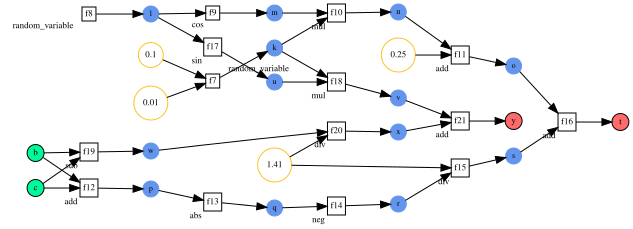

In [1]:
import jax 
import jax.numpy as jnp
import jax.random as jrandom
import math

from jax import core
from jax import lax
from jax._src.util import safe_map

import jax

from probjax.core.random_variable import rv, rv_p
import matplotlib.pyplot as plt
from probjax.distributions import Normal, Uniform

sqrt2 = math.sqrt(2)

def simulator_two_moons(key, theta0, theta1):
    """Simulator for the two moons problem."""
    key1, key2 = jrandom.split(key)
    p = Normal(0.1, 0.01)
    u = Uniform(-0.5 * jnp.pi, 0.5 * jnp.pi)
    noise1 = rv(p, "noise1")
    noise2 = rv(u, "noise2")
    r = noise1(key1)
    alpha = noise2(key2)
    rhs1 = (r * jnp.cos(alpha) + 0.25) + (-jnp.abs(theta0 + theta1) / sqrt2)
    rhs2 = (r * jnp.sin(alpha)) + ((theta1 - theta0) / sqrt2)

    return rhs1, rhs2

jaxpr = jax.make_jaxpr(simulator_two_moons)(jrandom.PRNGKey(1), jnp.ones(1), jnp.ones(1))
from probjax.core.graph import JaxprGraph, propagate, inverse_cost_fn
import networkx as nx
g = JaxprGraph(jaxpr.jaxpr.invars, jaxpr.jaxpr.constvars, jaxpr.jaxpr.outvars, jaxpr.jaxpr.eqns)
g.graph.remove_nodes_from(["a", "d", "e", "f", "g", "i", "j", "h", "f0", "f1", "f2", "f3", "f4", "f5", "f6"])
g

In [2]:
import haiku as hk 
from jax import Array 
import distrax
from typing import Optional, Sequence
import numpy as np


class Context(hk.Module):
  
  def __init__(self, context, name: str | None = None):
     super().__init__(name)
     self.context = context

  def __call__(self, x):
    x_new = jnp.concatenate([x, self.context], axis=-1)
    return x_new


def make_conditioner(context, event_shape: Sequence[int],
                     hidden_sizes: Sequence[int],
                     num_bijector_params: int) -> hk.Sequential:
  """Creates an MLP conditioner for each layer of the flow."""
 

  return hk.Sequential([
      Context(context),
      hk.nets.MLP(hidden_sizes, activate_final=True),
      # We initialize this linear layer to zero so that the flow is initialized
      # to the identity function.
      hk.Linear(
          np.prod(event_shape) * num_bijector_params,
          w_init=jnp.zeros,
          b_init=jnp.zeros),
      hk.Reshape(tuple(event_shape) + (num_bijector_params,), preserve_dims=-1),
  ])


def bijector_fn(params: Array):
    return distrax.RationalQuadraticSpline(
        params, range_min=-2, range_max=2.)

def make_flow(context, event_shape: Sequence[int], num_layers:int, hidden_sizes: Sequence[int], num_bins) -> distrax.Transformed:
    mask = jnp.arange(0, np.prod(event_shape)) % 2
    mask = jnp.reshape(mask, event_shape)
    mask = mask.astype(bool)

    num_bijector_params = 3 * num_bins + 1

    layers = []
    for _ in range(num_layers):
        layer = distrax.MaskedCoupling(
            mask=mask,
            bijector=bijector_fn,
            conditioner=make_conditioner(context, event_shape, hidden_sizes,
                                        num_bijector_params))
        layers.append(layer)
        # Flip the mask after each layer.
        mask = jnp.logical_not(mask)

    # We invert the flow so that the `forward` method is called with `log_prob`.
    flow = distrax.Inverse(distrax.Chain(layers))
    base_distribution = distrax.Independent(
        distrax.Uniform(
            low=-2.*jnp.ones(event_shape),
            high=2.*jnp.ones(event_shape)),
        reinterpreted_batch_ndims=len(event_shape))
    
    return distrax.Transformed(base_distribution, flow)


In [3]:
from probjax.core.transformations import trace_all

trace_simulator = trace_all(simulator_two_moons)

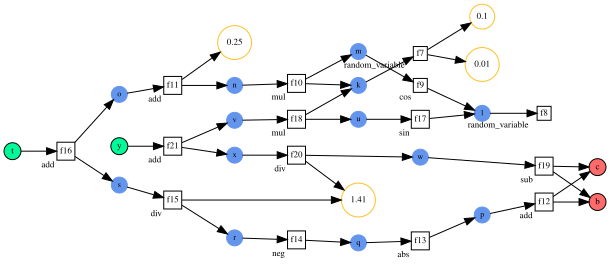

In [4]:
g.invert()

In [5]:
# propagate(graph=g.invert().graph, cost_fn=inverse_cost_fn, process_fn=lambda x,y,z: (x,y,z))

In [6]:
from probjax.core.stochastic_inverses.inverse_factorys import inverse_matrix_vector_multiplication
import distrax
import haiku as hk
import jax
from functools import partial

import jax.numpy as jnp

In [7]:
thetas = jrandom.uniform(jrandom.PRNGKey(1), shape=(100000, 2), minval=-2., maxval=2.)
xs = jnp.stack(jax.vmap(simulator_two_moons)(jrandom.split(jrandom.PRNGKey(2), 100000), thetas[:,0], thetas[:, 1]), axis=1)

traces = jax.vmap(trace_simulator)(jrandom.split(jrandom.PRNGKey(2), 100000),  thetas[:,0], thetas[:, 1])

In [8]:
@hk.without_apply_rng
@hk.transform
def sample(key, context):
    flow = make_flow(context,event_shape=(2,), num_layers=5, hidden_sizes=(50,50), num_bins=5)
    return flow.sample(seed=key)

@hk.without_apply_rng
@hk.transform
def log_prob(val, context):
    flow = make_flow(context,event_shape=(2,), num_layers=5, hidden_sizes=(50,50), num_bins=5)
    return flow.log_prob(val)

In [9]:
@partial(jax.vmap, in_axes=(None, 0,0))
@jax.jit
def log_prob_fn(params, x, context):
    return log_prob.apply(params, x, context)

@partial(jax.vmap, in_axes=(None, 0,None))
@jax.jit
def sample_fn(params, key, context):
    return sample.apply(params, key, context)

@jax.jit
def loss_fn(params, x,context):
    return -log_prob_fn(params, x,context).mean()

In [10]:
import optax
params = sample.init(jax.random.PRNGKey(42), jax.random.PRNGKey(0), jnp.ones(2))
x = sample.apply(params, jax.random.PRNGKey(0), jnp.ones(2))

optimizer = optax.adam(1e-2)
initial_opt_state = optimizer.init(params)

@jax.jit
def step(params, opt_state, x, context):
    values, grads = jax.value_and_grad(loss_fn)(params, x,context)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, values

x = jax.random.normal(jax.random.PRNGKey(0), (1000,2))*0.1 + 0.5
opt_state = initial_opt_state


In [11]:
for i in range(1000):
    idx = jax.random.choice(jax.random.PRNGKey(i), xs.shape[0], shape=(5012,), replace=False)
    params, opt_state, values = step(params, opt_state, thetas[idx], xs[idx])
    if (i % 100 )== 0:
        print(values)

2.7725887
-1.0908242
-1.5921701
-2.4023356
-2.0851095
-2.6635754
-2.436034
-2.812744
-2.279563
-2.4037588


In [13]:
theta_o = thetas[0]
x_o = xs[0]

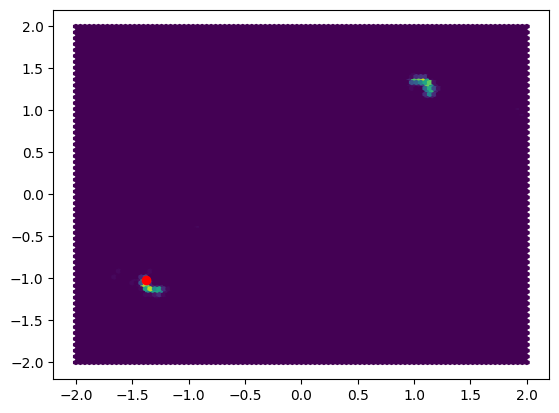

In [13]:
reference = sample_fn(params, jrandom.split(jax.random.PRNGKey(0), 1000), x_o)
plt.hexbin(reference[:,0], reference[:,1],extent=[-2,2,-2,2])
plt.scatter(theta_o[0], theta_o[1], color='red')

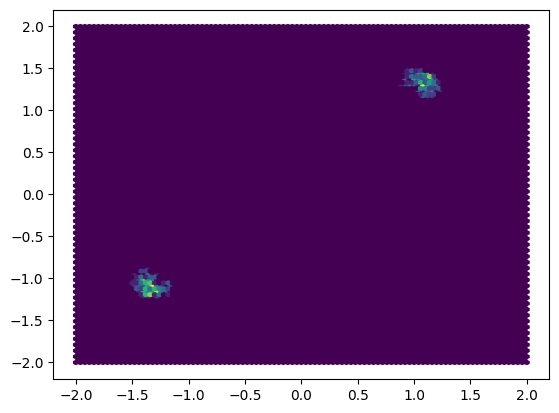

In [14]:
mask_abc = jnp.sum((xs - x_o)**2, -1) < 0.01
thetas_abc = thetas[mask_abc]

plt.hexbin(thetas_abc[:,0], thetas_abc[:,1],extent=[-2,2,-2,2])

In [14]:
p = traces["p"]
w = traces["w"]
target = jnp.stack((p,w))

b = traces["b"]
c = traces["c"]
value = jnp.stack((b,c))

A = jnp.array([[1.,1.], [-1., 1.]])



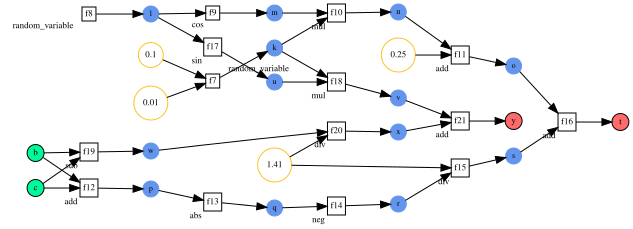

In [15]:
g

In [166]:
def inverse_two_moons(key, t,y):
    key1, key2, key3, key4 = jrandom.split(key, 4)
    q_o = f1(params1, jnp.asarray(t))
    o = q_o.sample(seed=key1)
    #o = jrandom.normal(key1, (2,))*0.1
    n = o - 0.25 
    s = t - o 
    r = s * 1.4142135623730951
    q_k = f2(params2, jnp.asarray(n))
    k = q_k.sample(seed=key2).squeeze()
    m = n/k
    m = jnp.clip(n/k, 0.000001, 1.)
    #l = jrandom.uniform(key2, (1,), minval=-0.5 * jnp.pi, maxval=0.5 * jnp.pi).squeeze()
    l = jnp.arccos(m) * jrandom.choice(key3, jnp.asarray([-1., 1.]))
    u = jnp.sin(l)
    v = k * u
    x = y - v 
    w = x * 1.4142135623730951
    q = -r 
    p = jrandom.choice(key4, jnp.asarray([-1., 1.])) * q 
    target = jnp.stack([p, w], 0).squeeze()
    out = jnp.linalg.solve(A, target).T
    out = jnp.clip(out, -2, 2)
    return out.split(2), m,k,l,u,v





    

In [167]:
theta_inv = jax.vmap(inverse_two_moons, in_axes=(0, None, None))(jrandom.split(jrandom.PRNGKey(2), 100000), x_o[0].reshape(-1,1), x_o[1].reshape(-1,1))

/root/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/numpy/array_methods.py:329: FutureWarning: The arr.split() method is deprecated. Use jax.numpy.split instead.
  warnings.warn(


In [168]:
# theta_inv

In [169]:
def abc_dist(var, x_o):
    mask = jnp.sum((xs - x_o)**2, axis=-1) < 0.01
    return traces[var][mask]

In [170]:
import numpy as np

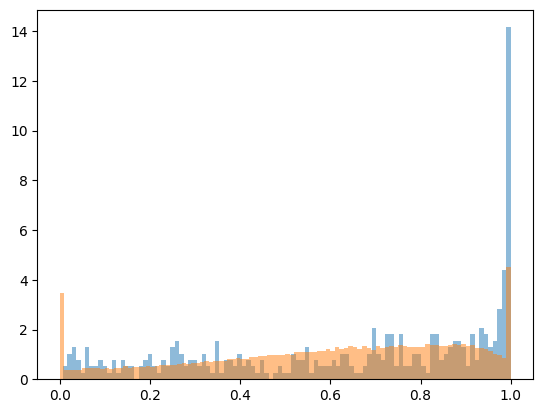

In [172]:
plt.hist(np.array(jnp.nan_to_num(abc_dist("m", x_o))), alpha=0.5, density=True, bins=100)
_ = plt.hist(np.array(jnp.squeeze(jnp.nan_to_num(theta_inv[-5]))), alpha=0.5, density=True,bins=100)
# plt.xlim(-0.5,0.5)

(-0.5, 0.5)

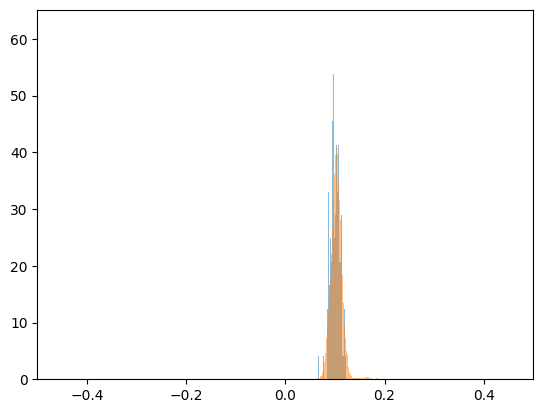

In [173]:
plt.hist(np.array(jnp.nan_to_num(abc_dist("k", x_o))), alpha=0.5, density=True, bins=100)
_ = plt.hist(np.array(jnp.squeeze(jnp.nan_to_num(theta_inv[-4]))), alpha=0.5, density=True,bins=100)
plt.xlim(-0.5,0.5)

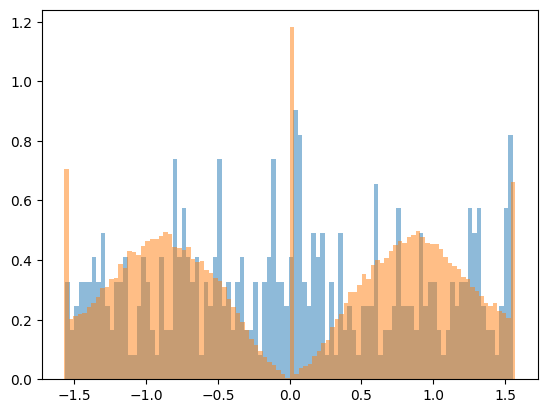

In [174]:
plt.hist(np.array(jnp.nan_to_num(abc_dist("l", x_o))), alpha=0.5, density=True, bins=100)
_ = plt.hist(np.array(jnp.squeeze(jnp.nan_to_num(theta_inv[-3]))), alpha=0.5, density=True,bins=100)

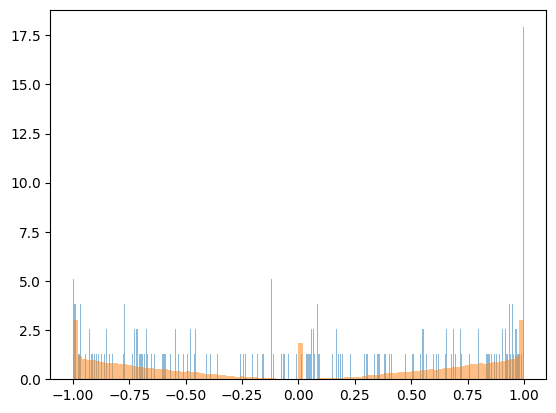

In [175]:
plt.hist(np.array(jnp.nan_to_num(abc_dist("u", x_o))), alpha=0.5, density=True, bins=1000)
_ = plt.hist(np.array(jnp.squeeze(jnp.nan_to_num(theta_inv[-2]))), alpha=0.5, density=True,bins=100)

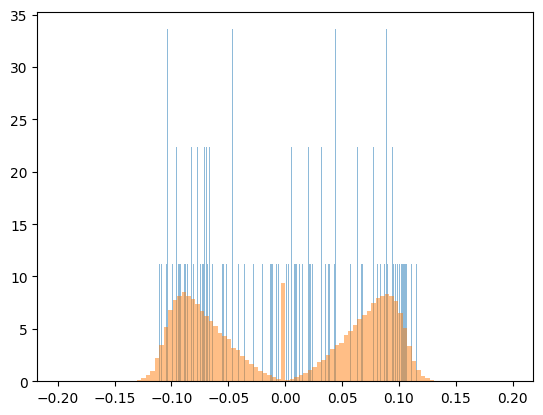

In [176]:
plt.hist(np.array(jnp.nan_to_num(abc_dist("v", x_o))), alpha=0.5, density=True, bins=1000)
_ = plt.hist(np.array(jnp.squeeze(jnp.nan_to_num(theta_inv[-1]))), alpha=0.5, density=True,bins=100)

In [177]:
# plt.hist(np.array(jnp.nan_to_num(abc_dist("b", x_o))), alpha=0.5, density=True, bins=100)
# _ = plt.hist(np.array(jnp.nan_to_num(theta_inv[0])), alpha=0.5, density=True,bins=100)

In [178]:
theta_inv = theta_inv[0]

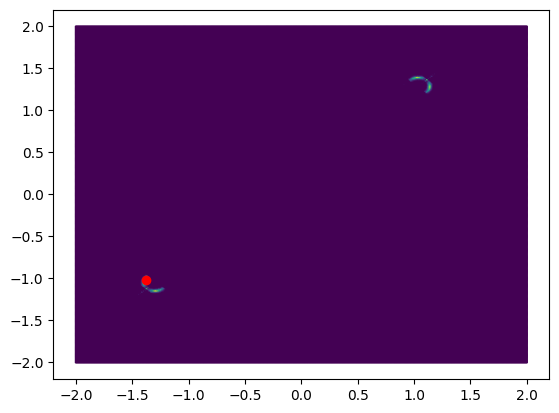

In [184]:
plt.hexbin(theta_inv[0], theta_inv[1], extent=[-2,2,-2,2], gridsize=500)
plt.scatter(theta_o[0], theta_o[1], color="red")

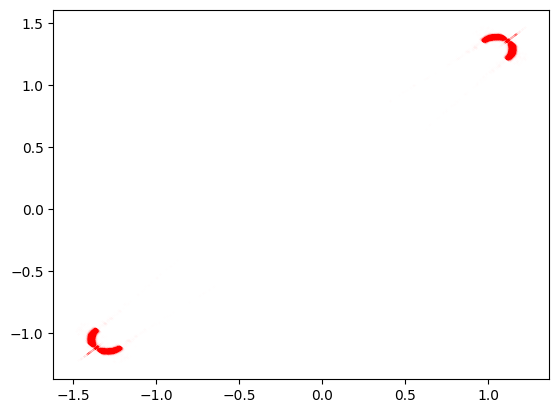

In [180]:
plt.scatter(theta_inv[0], theta_inv[1], color="red", alpha=0.01, s=0.1)

In [56]:
xs.min(0), xs.max(0)

(Array([-2.5395248, -2.8982925], dtype=float32),
 Array([0.37128523, 2.9151583 ], dtype=float32))

In [146]:
@hk.without_apply_rng
@hk.transform
def model(x):
    mlp = hk.Sequential([
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(46),
        hk.Reshape(tuple((1,)) + (46,), preserve_dims=-1),
    ])
    out = mlp(x)
    t = distrax.RationalQuadraticSpline(out, range_min=-0.5, range_max=0.5)
    #transforms = distrax.Chain([distrax.ScalarAffine(x + 0.1, -1.),distrax.Lambda(lambda x: jnp.exp(x)),t])
    transforms = distrax.Chain([t])
    #return distrax.Transformed(distrax.Normal(0, 1.), transforms)
    return distrax.Transformed(distrax.Uniform(-0.5, 0.5), transforms)

params1 = model.init(jax.random.PRNGKey(42), jnp.ones((1,)))
f1 = model.apply


In [147]:
def rbf_kernel(X, Y, gamma):
    """
    Computes the RBF kernel between two matrices X and Y.
    """
    XX = jnp.sum(X**2, axis=-1, keepdims=True)
    YY = jnp.sum(Y**2, axis=-1, keepdims=True)
    XY = jnp.dot(X, Y.T)
    K = 10*jnp.exp(-gamma * (XX - 2 * XY + YY.T))
    return K


def mmd(X, Y, gamma):
    """
    Computes the Maximum Mean Discrepancy (MMD) between two sets of samples X and Y.
    """
    K_XX = rbf_kernel(X, X, gamma)
    K_XY = rbf_kernel(X, Y, gamma)
    K_YY = rbf_kernel(Y, Y, gamma)
    mmd = jnp.mean(K_XX) - 2 * jnp.mean(K_XY) + jnp.mean(K_YY)
    return mmd

In [148]:
x1 = traces["t"].reshape(-1,1)
o1 =traces["o"].reshape(-1,1)
s1 = traces["s"].reshape(-1,1)

from functools import partial



@partial(jax.vmap, in_axes=(None, 0,0,0,0))
def loss_fn(params, x, latents, s1, rng):
    q = f1(params, x)
    samples = q.sample(seed=rng)
    log_prob = q.log_prob(latents)
    return -jnp.mean(log_prob) + mmd(x - samples, s1, .5)

@jax.jit 
@jax.value_and_grad
def loss_grad(params, x1, o1, s1, rng):
    
    return loss_fn(params, x1, o1, s1, rng).mean()


import optax 

opt = optax.adam(0.01)
opt_state = opt.init(params1)

for i in range(1000):
    idx = jax.random.choice(jax.random.PRNGKey(i), x1.shape[0], shape=(1024,), replace=False)
    value, gradient = loss_grad(params1, x1[idx], o1[idx], s1[idx], jrandom.split(jax.random.PRNGKey(-1000 + i), idx.shape[0]))
    updates, opt_state = opt.update(gradient,opt_state)
    params1 = optax.apply_updates(params1, updates)
    if (i % 100) == 0:
        print(value)




1.3021045
-1.9811614
-2.0688975
-2.07719
-2.0600643
-1.9908586
-1.9779845
-2.0795674
-2.0042512
-2.0604448


In [163]:
@hk.without_apply_rng
@hk.transform
def model(x):
    mlp = hk.Sequential([
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(100), jax.nn.relu,
        hk.Linear(46),
        hk.Reshape(tuple((1,)) + (46,), preserve_dims=-1),
    ])
    out = mlp(x)
    t = distrax.RationalQuadraticSpline(out, range_min=0., range_max=0.2)
    #transforms = distrax.Chain([distrax.ScalarAffine(x + 0.1, -1.),distrax.Lambda(lambda x: jnp.exp(x)),t])
    #return distrax.Transformed(distrax.Normal(0, 1.), transforms)
    return distrax.Transformed(distrax.Uniform(0., 0.2), t)

params2 = model.init(jax.random.PRNGKey(42), jnp.ones((1,)))
f2 = model.apply


In [164]:
o1.min()

Array(0.05417276, dtype=float32)

In [165]:
x1 = traces["n"].reshape(-1,1)
o1 = traces["k"].reshape(-1,1)
m1 = traces["m"].reshape(-1,1)
from functools import partial


@partial(jax.vmap, in_axes=(None, 0,0,0,0))
def loss_fn(params, x, latents, m1, rng):
    q = f2(params, x)
    samples = q.sample(seed=rng)
    log_prob = q.log_prob(latents)
    return -jnp.mean(log_prob) + mmd(x/samples, m1, .5)

@jax.jit 
@jax.value_and_grad
def loss_grad(params, x1, o1, m1, rng):
    
    return loss_fn(params, x1, o1, m1, rng).mean()


import optax 

opt = optax.adam(0.01)
opt_state = opt.init(params2)

for i in range(1000):
    idx = jax.random.choice(jax.random.PRNGKey(i), x1.shape[0], shape=(1024,), replace=False)
    value, gradient = loss_grad(params2, x1[idx], o1[idx], m1[idx], jrandom.split(jax.random.PRNGKey(-1000 + i), idx.shape[0]))
    updates, opt_state = opt.update(gradient,opt_state)
    params2 = optax.apply_updates(params2, updates)
    if (i % 100) == 0:
        print(value)




2.134046
-3.0212212
-3.1783688
-3.30816
-3.0703404
-2.9451194
-3.2025423
-3.100194
-3.1444235
-3.1889067


In [ ]:
import heapq

class PriorityQueue:
    def __init__(self):
        self.heap = []
        self.entry_finder = {}
        self.counter = 0

    def insert(self, element, cost):
        if element in self.entry_finder:
            self.remove(element)
        entry = [cost, self.counter, element]
        self.entry_finder[element] = entry
        heapq.heappush(self.heap, entry)
        self.counter += 1

    def __contains__(self, element):
        return element in self.entry_finder

    def remove(self, element):
        entry = self.entry_finder.pop(element)
        entry[-1] = None

    def update_cost(self, element, new_cost):
        self.remove(element)
        self.insert(element, new_cost)

    def pop(self):
        while self.heap:
            _, _, element = heapq.heappop(self.heap)
            if element is not None:
                del self.entry_finder[element]
                return element
        raise IndexError("Priority queue is empty.")

    def is_empty(self):
        return len(self.entry_finder) == 0




def topological_sort(graph, cost_function=None):

    if cost_function is None:
        cost_function = lambda *args, **kwargs: 0

    sorted_nodes = []
    in_degree = dict(graph.in_degree())

    # Enqueue nodes with in-degree 0
    queue = PriorityQueue()
    for node in in_degree:
        if in_degree[node] == 0:
            queue.insert(node, 0)

    while queue.is_empty() == False:
        # Dequeue a node
        current_node = queue.pop()
        sorted_nodes.append(current_node)

        # Decrease in-degree of adjacent nodes
        for neighbor in graph.neighbors(current_node):
            in_degree[neighbor] -= 1
            if in_degree[neighbor] == 0:
                queue.insert(neighbor, cost_function(graph, neighbor))

    # Check for a cycle in the graph
    if len(sorted_nodes) != len(graph):
        return "Error: The graph contains a cycle and cannot be sorted."

    return sorted_nodes

topological_sort(g.invert().graph, cost_function=lambda graph, n: graph.in_degree[n])

['t',
 'y',
 'f16',
 'f21',
 'o',
 's',
 'v',
 'x',
 'f11',
 'f15',
 'f18',
 'f20',
 'n',
 '0.25',
 'r',
 'u',
 'w',
 'f10',
 'f14',
 'f17',
 'f19',
 'm',
 'q',
 'f9',
 'f13',
 'p',
 'f12',
 '1.41',
 'k',
 'f7',
 '0.01',
 '0.1',
 'l',
 'f8',
 'b',
 'c']

In [2]:
#nx.single_source_shortest_path_length(g.graph,"u")

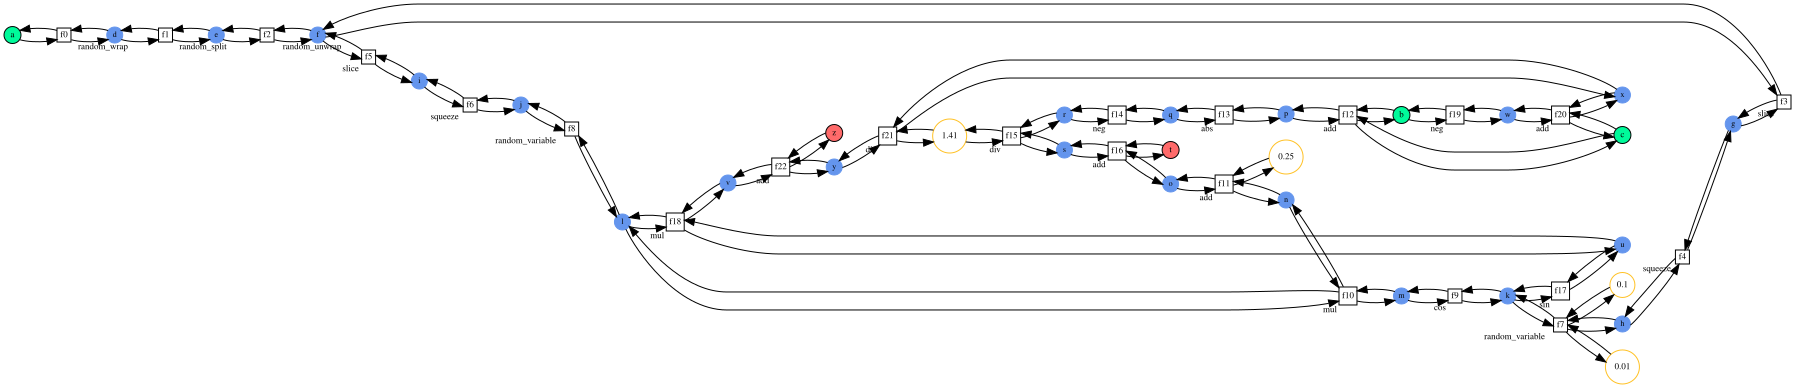

In [9]:
g.graph.add_edges_from([(v, u) for u, v in g.graph.edges()])
G = g.graph
g

In [10]:
nx.

(16,
 ['z',
  'f22',
  'v',
  'f18',
  'l',
  'f8',
  'j',
  'f6',
  'i',
  'f5',
  'f',
  'f2',
  'e',
  'f1',
  'd',
  'f0',
  'a'])

In [11]:
nx.multi_source_dijkstra(G, ["z", "t"], "b")

(8, ['z', 'f22', 'y', 'f21', 'x', 'f20', 'c', 'f12', 'b'])

In [5]:
cache = set()
G = g.graph
def weight_fn(edge, **kwargs):
    n1, n2 = edge
    tag1 = G.nodes[n1]["tag"]
    tag2 = G.nodes[n2]["tag"]
    if tag1 == "operation":
        eqn = g.eqns[G.nodes[n1]["index"]]
        var = G.nodes[n2]["var"]

        if len(eqn.invars) == 1:
            cache.add(var)
            return 1
        else:
            

    else:
        eqn = g.eqns[G.nodes[n2]["index"]]
        var = G.nodes[n1]["var"]

    num_invars = len(eqn.invars)

    if num_invars == 1:
        cache.add(var)
        return 1
    else:
        is_forward = var in eqn.outvars

    eqns = g.eqns 
    index = int()
    print(args, kwargs)
    return 1

In [7]:
nx.shortest_path(g.graph, "z", "b", weight=weight_fn)

('z', 'f22', {}) {}
('f12', 'b', {}) {}
('f19', 'b', {}) {}
('f22', 'z', {}) {}
('f22', 'v', {}) {}
('f22', 'y', {}) {}
('b', 'f12', {}) {}
('c', 'f12', {}) {}
('p', 'f12', {}) {}
('v', 'f22', {}) {}
('v', 'f18', {}) {}
('b', 'f19', {}) {}
('w', 'f19', {}) {}
('y', 'f22', {}) {}
('y', 'f21', {}) {}
('f12', 'c', {}) {}
('f20', 'c', {}) {}
('f18', 'v', {}) {}
('f18', 'l', {}) {}
('f18', 'u', {}) {}
('f12', 'p', {}) {}
('f13', 'p', {}) {}
('f21', 'y', {}) {}
('f21', '1.41', {}) {}
('f21', 'x', {}) {}
('f19', 'w', {}) {}
('f20', 'w', {}) {}
('l', 'f10', {}) {}
('l', 'f18', {}) {}
('l', 'f8', {}) {}
('w', 'f20', {}) {}
('c', 'f20', {}) {}
('x', 'f20', {}) {}
('u', 'f18', {}) {}
('u', 'f17', {}) {}
('p', 'f13', {}) {}
('q', 'f13', {}) {}
('1.41', 'f15', {}) {}
('1.41', 'f21', {}) {}
('f20', 'x', {}) {}
('f21', 'x', {}) {}


['z', 'f22', 'y', 'f21', 'x', 'f20', 'c', 'f12', 'b']

In [74]:
nx.set_edge_attributes(g.graph, [1.] * len(g.graph.edges), "weight")

In [75]:
g.graph.get_edge_data("u", "v")

In [27]:
AGraph.nodes()[0].attr["style"] = "filled"

In [2]:
AGraph = nx.nx_agraph.to_agraph(g.graph)

In [12]:
AGraph.nodes()

['a',
 'b',
 'c',
 't',
 'z',
 'f0',
 'd',
 'f1',
 'e',
 'f2',
 'f',
 'f3',
 'g',
 'f4',
 'h',
 'f5',
 'i',
 'f6',
 'j',
 'f7',
 '0.01',
 '0.099999994',
 'k',
 'f8',
 'l',
 'f9',
 'm',
 'f10',
 'n',
 'f11',
 '0.25',
 'o',
 'f12',
 'p',
 'f13',
 'q',
 'f14',
 'r',
 'f15',
 '1.41',
 's',
 'f16',
 'f17',
 'u',
 'f18',
 'v',
 'f19',
 'w',
 'f20',
 'x',
 'f21',
 'y',
 'f22']

In [8]:
g.graph.reverse()

TypeError: cannot pickle 'jaxlib.xla_extension.Traceback' object

In [79]:
import jax._src.interpreters.partial_eval as pe

jaxpr1, jaxpr2, outs,_ = pe.partial_eval_jaxpr_nounits(jaxpr, [False, False, True], False)
outs

[True, True]

In [97]:
jaxpr2.jaxpr.outvars

[h, m]

In [96]:
jaxpr2.jaxpr.invars

[a, b, i, j, c]

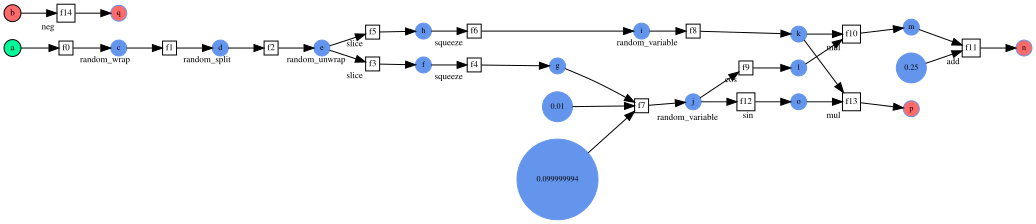

In [95]:
g1  = FactorGraph(jaxpr1.jaxpr)
g1

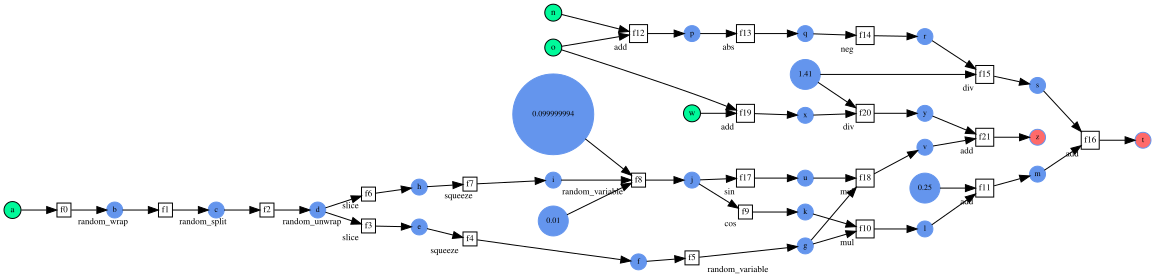

In [70]:
g2  = FactorGraph(jaxpr2.jaxpr)
g2

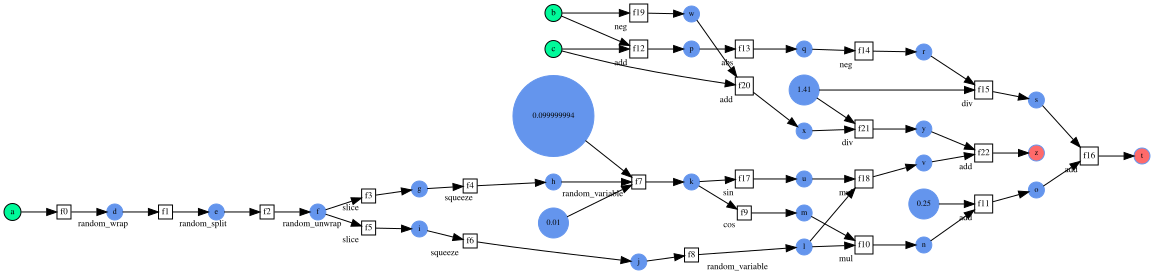

In [84]:
from probjax.core.graph import FactorGraph
import networkx as nx
g = FactorGraph(jaxpr.jaxpr)
g

In [91]:
nx.

NetworkXNotImplemented: not implemented for directed type

In [88]:
list(nx.all_simple_paths(g.graph, "a", "t"))

[['a',
  'f0',
  'd',
  'f1',
  'e',
  'f2',
  'f',
  'f3',
  'g',
  'f4',
  'h',
  'f7',
  'k',
  'f9',
  'm',
  'f10',
  'n',
  'f11',
  'o',
  'f16',
  't'],
 ['a',
  'f0',
  'd',
  'f1',
  'e',
  'f2',
  'f',
  'f5',
  'i',
  'f6',
  'j',
  'f8',
  'l',
  'f10',
  'n',
  'f11',
  'o',
  'f16',
  't']]

In [78]:
jaxpr.jaxpr.invars

[a, b, c]

In [3]:
def inverse_simulator(key, x_1, x_2):
    """Inverse simulator for the two moons problem."""
    key1, key2 = jrandom.split(key)
    u1 = jrandom.normal(key1)
    z1 = sqrt2 * (x_2 - u1)
    

(Array(-1.6905036, dtype=float32), Array(-0.12554535, dtype=float32))

In [11]:
def eval_jaxpr(jaxpr, consts, *args):
  # Mapping from variable -> value
  env = {}
  
  def read(var):
    # Literals are values baked into the Jaxpr
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val

  # Bind args and consts to environment
  safe_map(write, jaxpr.invars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Loop through equations and evaluate primitives using `bind`
  for eqn in jaxpr.eqns:
    # Read inputs to equation from environment
    
    invals = safe_map(read, eqn.invars)  
    # `bind` is how a primitive is called
    outvals = eqn.primitive.bind(*invals, **eqn.params)
    # Primitives may return multiple outputs or not
    if not eqn.primitive.multiple_results: 
      outvals = [outvals]
    # Write the results of the primitive into the environment
    safe_map(write, eqn.outvars, outvals) 
  # Read the final result of the Jaxpr from the environment
  return safe_map(read, jaxpr.outvars) 

In [3]:
def eval_jaxpr_and_trace(jaxpr, consts, *args):
  # Mapping from variable -> value
  env = {}
  
  def read(var):
    # Literals are values baked into the Jaxpr
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val

  # Bind args and consts to environment
  safe_map(write, jaxpr.invars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Loop through equations and evaluate primitives using `bind`
  for eqn in jaxpr.eqns:
    # Read inputs to equation from environment
    
    invals = safe_map(read, eqn.invars)  
    # `bind` is how a primitive is called
    outvals = eqn.primitive.bind(*invals, **eqn.params)
    # Primitives may return multiple outputs or not
    if not eqn.primitive.multiple_results: 
      outvals = [outvals]
    # Write the results of the primitive into the environment
    safe_map(write, eqn.outvars, outvals) 
  # Read the final result of the Jaxpr from the environment
  return safe_map(read, jaxpr.outvars), env

In [4]:
def trace(key, *args):
    return eval_jaxpr_and_trace(jaxpr.jaxpr, jaxpr.consts, key, *args)[-1]

batched_trace = jax.vmap(trace)

In [131]:
x_o = 4.

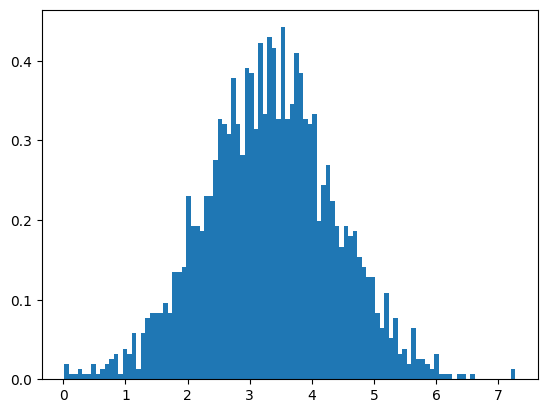

In [132]:
env = batched_trace(jrandom.split(jrandom.PRNGKey(1), 100000), jrandom.normal(jrandom.PRNGKey(2), shape=(100000,)))
noise_dist = list(env.values())[-1]
mask = (noise_dist - x_o)**2 < 0.1
noise_dist = list(env.values())[-3][mask.flatten()]
_ = plt.hist(noise_dist.flatten(), bins=100, density=True)

In [133]:
inverse_registry = {}


def pow_stochastic_inverse(key, eqn):
    exponent = eqn.params["y"]
    if (exponent % 2) == 1:
        return key, lambda x: x**(1/exponent)
    else:
        key1, key2 = jrandom.split(key)
        sign = jrandom.choice(key2, jnp.asarray([-1, 1]))
        return key1, lambda x: sign * x**(1/exponent)
    

def stochastic_add(key, eqn):
    key1, key2 = jrandom.split(key)

    def inverse_add(c):
        #noise = jrandom.normal(key2, shape=c.shape)
        noise = jrandom.choice(key2,noise_dist.flatten(), shape=c.shape)
        out1 = noise
        out2 = c - noise
        return [out1, out2]
    return key1, inverse_add

    

inverse_registry[lax.exp_p] = lambda key,eqn: (key, jnp.log)
inverse_registry[lax.tanh_p] = lambda key, eqn: (key, jnp.arctanh)
inverse_registry[lax.integer_pow_p] = pow_stochastic_inverse
inverse_registry[lax.add_p] = stochastic_add

In [134]:
def inverse_jaxpr(jaxpr, consts, key,*args):
  env = {}
  
  def read(var):
    if type(var) is core.Literal:
      return var.val
    return env[var]

  def write(var, val):
    env[var] = val
  # Args now correspond to Jaxpr outvars
  safe_map(write, jaxpr.outvars, args)
  safe_map(write, jaxpr.constvars, consts)

  # Looping backward
  for eqn in jaxpr.eqns[::-1]:
    if eqn.primitive is rv_p:
      safe_map(write, [eqn.invars[-1]], [key])
      continue
    #  outvars are now invars 
    invals = safe_map(read, eqn.outvars)
    if eqn.primitive not in inverse_registry:
      raise NotImplementedError(
          f"{eqn.primitive} does not have registered inverse.")
    else:
      key, inverse = inverse_registry[eqn.primitive](key, eqn)
      outval = inverse(*invals)
    # Assuming a unary function 
    if not isinstance(outval, list):
      outval = [outval]

    safe_map(write, eqn.invars, outval)
  return safe_map(read, jaxpr.invars), env

In [135]:


out = inverse_jaxpr(jaxpr.jaxpr, jaxpr.consts, jrandom.PRNGKey(0), jnp.asarray([2]))

In [136]:
def inverse_simulator(key, *args):
    return inverse_jaxpr(jaxpr.jaxpr, jaxpr.consts, key, *args)

In [137]:
batched_trace = jax.vmap(trace)
batched_inverse_f = jax.vmap(inverse_simulator)

In [138]:

posterior_samples = batched_inverse_f(jrandom.split(jrandom.PRNGKey(1), 100000), jnp.ones((100000,1))*x_o)

In [139]:
def log_potential(theta,x):
    z = theta**2
    return Normal(z,1.).log_prob(x) + Normal(0.,1.).log_prob(theta)
x = jnp.linspace(-10,10,1000)
unnormalized_posterior =jnp.exp(jax.vmap(log_potential)(x, jnp.ones(1000)*x_o))
posterior = unnormalized_posterior / jnp.trapz(unnormalized_posterior, x)


In [140]:
import matplotlib.pyplot as plt

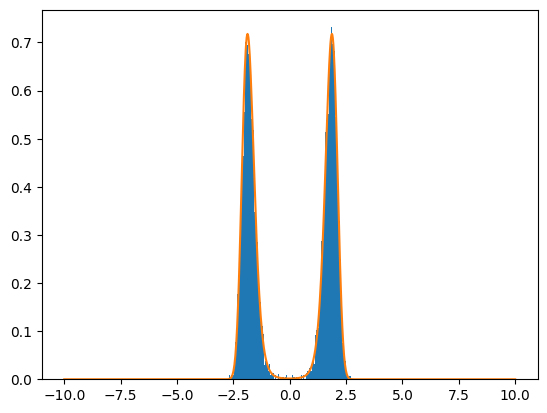

In [141]:
_ = plt.hist(posterior_samples[0][1].flatten(), bins=100, density=True)
plt.plot(x, posterior)

In [150]:
index = -3

list(posterior_samples[1].keys())[index]

e

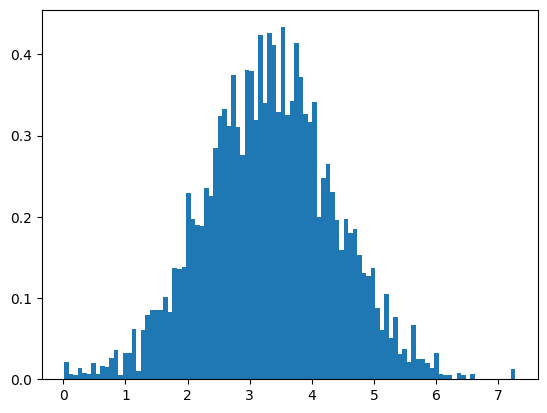

In [151]:
_ = plt.hist(list(posterior_samples[1].values())[index].flatten(), bins=100, density=True)

In [152]:
list(env.keys())[index]

e

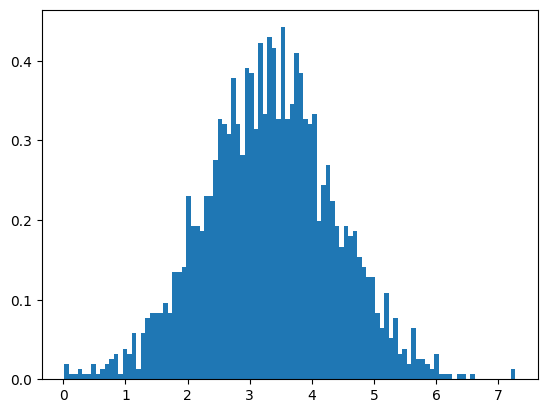

In [153]:
_ = plt.hist(list(env.values())[index][mask.flatten()].flatten(), bins=100, density=True)